In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

df = pd.read_csv("../data/raw/indian_telecom_churn.csv")
df.head()

,customer_id,name,age,gender,circle,circle_type,operator,plan_type,plan_amount_inr,tenure_months,data_usage_gb,days_since_last_recharge,num_complaints_6m,network_rating,payment_method,has_bundle,uses_5g,is_active_vlr,churn,registration_date
0,CUST100000,Aryan Maharaj,24,Male,Tamil Nadu,Urban,Jio,Prepaid,239,15,15.8,6,1,3,Cash/Retail Recharge,1,1,1,0,2017-04-14
1,CUST100001,Udant Dewan,41,Male,Karnataka,Urban,BSNL,Postpaid,599,31,1.4,11,0,3,Debit/Credit Card,0,0,0,0,2018-09-08
2,CUST100002,Gagan Sami,49,Female,Mumbai,Metro,Airtel,Prepaid,199,116,2.6,41,0,5,Cash/Retail Recharge,0,0,1,0,2017-05-15
3,CUST100003,Ayushman Chander,19,Male,UP East,Rural,Airtel,Prepaid,199,1,7.9,5,1,4,Debit/Credit Card,0,0,1,0,2022-05-15
4,CUST100004,Viraj Tiwari,54,Male,Gujarat,Urban,Jio,Prepaid,149,6,5.3,1,1,3,Cash/Retail Recharge,0,0,1,0,2019-07-03


In [2]:
print("Shape:", df.shape)
df.info()

Shape: (10000, 20)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  str    
 1   name                      10000 non-null  str    
 2   age                       10000 non-null  int64  
 3   gender                    10000 non-null  str    
 4   circle                    10000 non-null  str    
 5   circle_type               10000 non-null  str    
 6   operator                  10000 non-null  str    
 7   plan_type                 10000 non-null  str    
 8   plan_amount_inr           10000 non-null  int64  
 9   tenure_months             10000 non-null  int64  
 10  data_usage_gb             10000 non-null  float64
 11  days_since_last_recharge  10000 non-null  int64  
 12  num_complaints_6m         10000 non-null  int64  
 13  network_rating            10000 non-null  int64  
 14 

In [3]:
df.isnull().sum()


customer_id                 0
name                        0
age                         0
gender                      0
circle                      0
circle_type                 0
operator                    0
plan_type                   0
plan_amount_inr             0
tenure_months               0
data_usage_gb               0
days_since_last_recharge    0
num_complaints_6m           0
network_rating              0
payment_method              0
has_bundle                  0
uses_5g                     0
is_active_vlr               0
churn                       0
registration_date           0
dtype: int64

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,10000,10000,CUST100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,10000,9814,Charvi Dara,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,10000.0,NaN,NaN,NaN,34.0507,10.944163,18.0,25.0,34.0,42.0,75.0
gender,10000,2,Male,5799,NaN,NaN,NaN,NaN,NaN,NaN,NaN
circle,10000,17,Delhi,954,NaN,NaN,NaN,NaN,NaN,NaN,NaN
circle_type,10000,3,Urban,4657,NaN,NaN,NaN,NaN,NaN,NaN,NaN
operator,10000,4,Jio,3976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plan_type,10000,2,Prepaid,8501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
plan_amount_inr,10000.0,NaN,NaN,NaN,346.044,182.650974,149.0,199.0,299.0,399.0,1199.0
tenure_months,10000.0,NaN,NaN,NaN,23.3653,22.776623,1.0,6.0,16.0,33.0,120.0


In [5]:
churn_rate = df["churn"].mean()
print(f"Overall churn rate: {churn_rate:.2%}")
df["churn"].value_counts(normalize=True)

Overall churn rate: 10.18%


churn
0    0.8982
1    0.1018
Name: proportion, dtype: float64

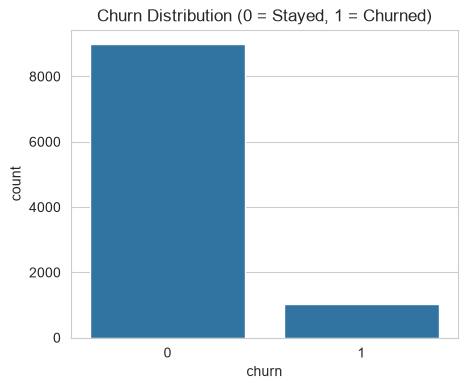

In [6]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="churn")
plt.title("Churn Distribution (0 = Stayed, 1 = Churned)")
plt.show()

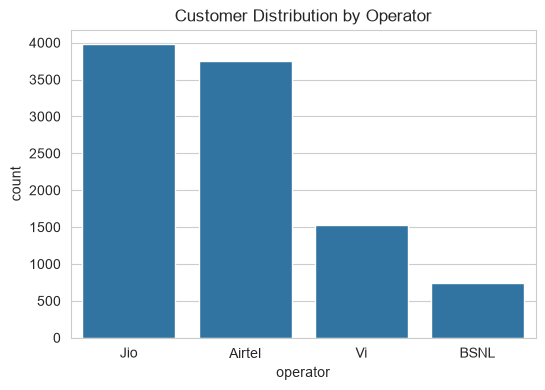

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="operator", order=df["operator"].value_counts().index)
plt.title("Customer Distribution by Operator")
plt.show()

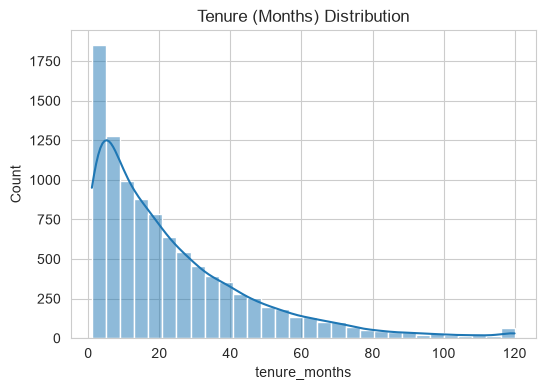

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df["tenure_months"], bins=30, kde=True)
plt.title("Tenure (Months) Distribution")
plt.show()

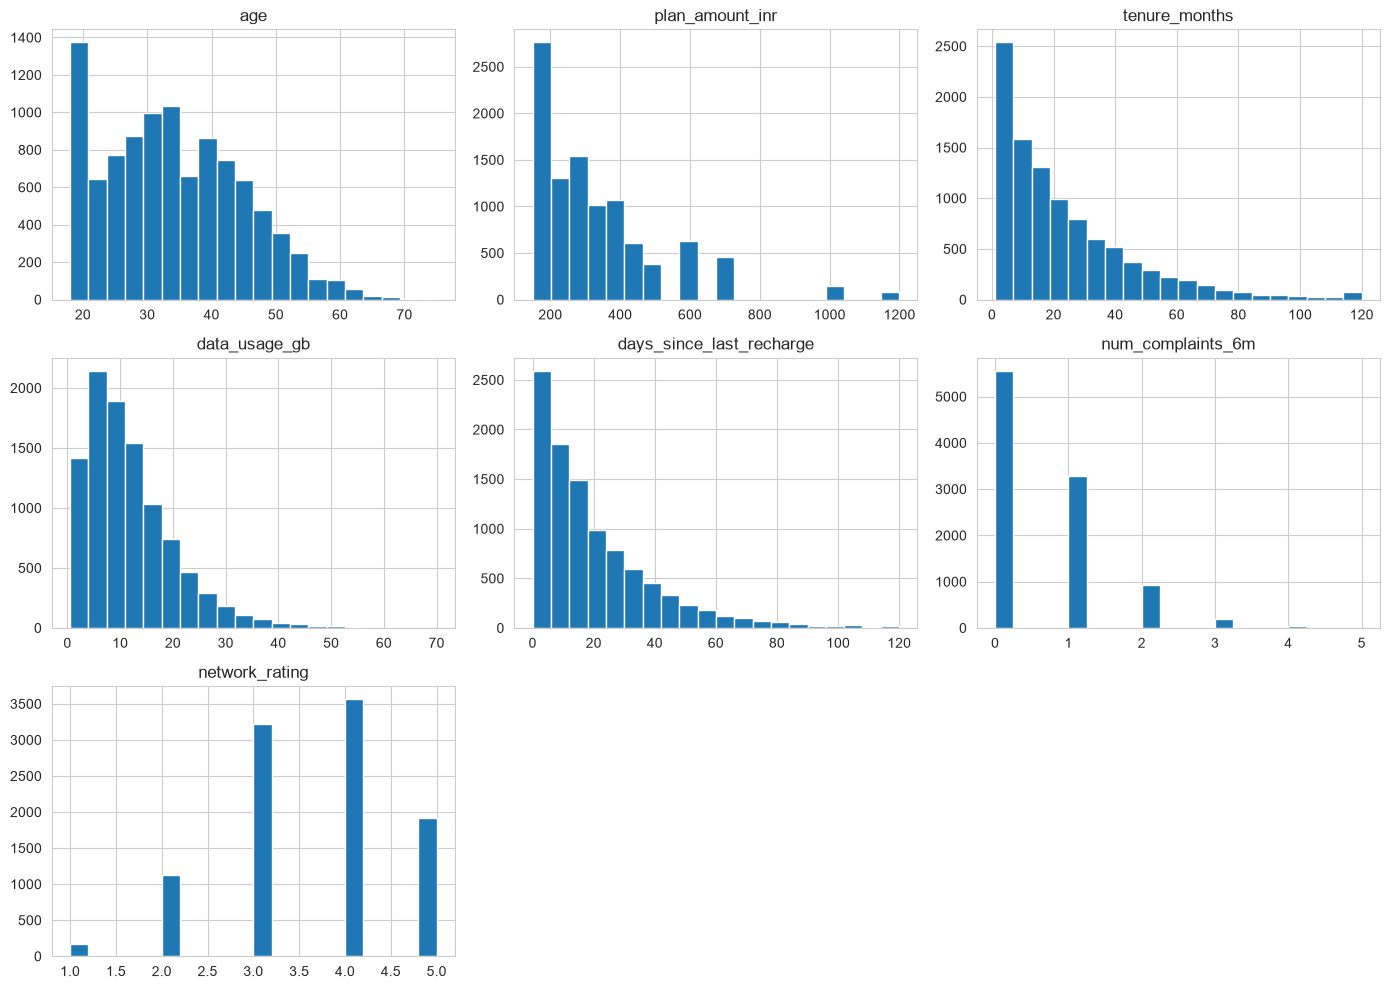

In [9]:
numeric_cols = ["age", "plan_amount_inr", "tenure_months", "data_usage_gb",
                 "days_since_last_recharge", "num_complaints_6m", "network_rating"]

df[numeric_cols].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

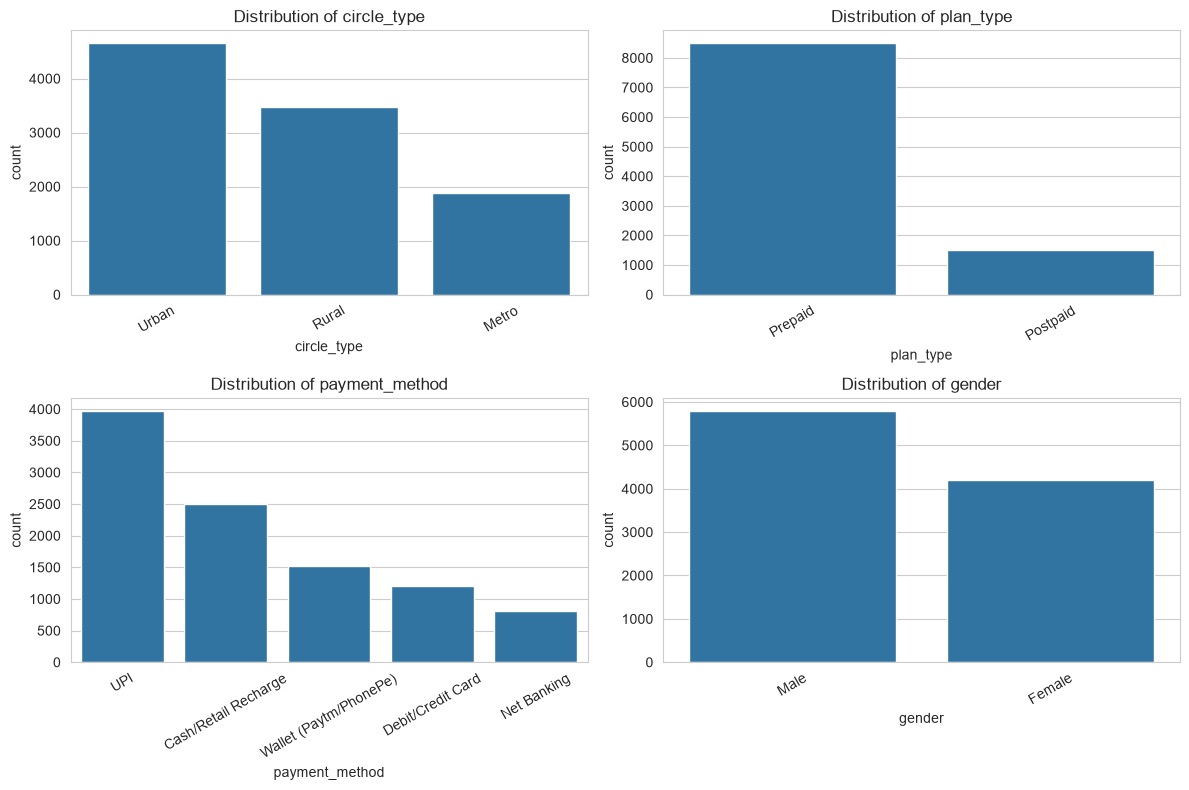

In [10]:
categorical_cols = ["circle_type", "plan_type", "payment_method", "gender"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), categorical_cols):
    sns.countplot(data=df, x=col, ax=ax, order=df[col].value_counts().index)
    ax.set_title(f"Distribution of {col}")
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

operator
BSNL      0.221477
Vi        0.212459
Airtel    0.071391
Jio       0.065644
Name: churn, dtype: float64


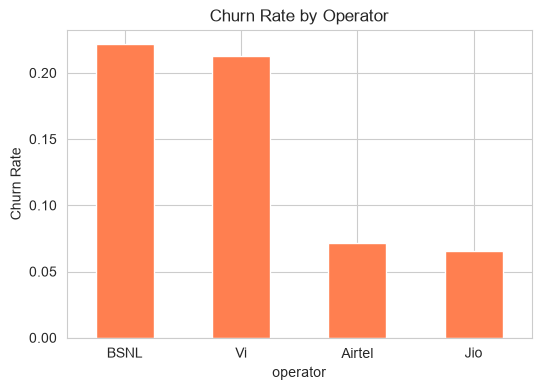

In [11]:
churn_by_operator = df.groupby("operator")["churn"].mean().sort_values(ascending=False)
print(churn_by_operator)

plt.figure(figsize=(6,4))
churn_by_operator.plot(kind="bar", color="coral")
plt.title("Churn Rate by Operator")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

circle_type
Urban    0.106721
Rural    0.097835
Metro    0.096912
Name: churn, dtype: float64


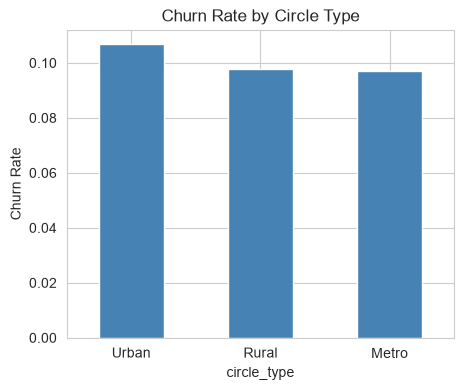

In [12]:
churn_by_circle = df.groupby("circle_type")["churn"].mean().sort_values(ascending=False)
print(churn_by_circle)

plt.figure(figsize=(5,4))
churn_by_circle.plot(kind="bar", color="steelblue")
plt.title("Churn Rate by Circle Type")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

num_complaints_6m
0    0.093165
1    0.093541
2    0.170784
3    0.144330
4    0.187500
5    0.000000
Name: churn, dtype: float64


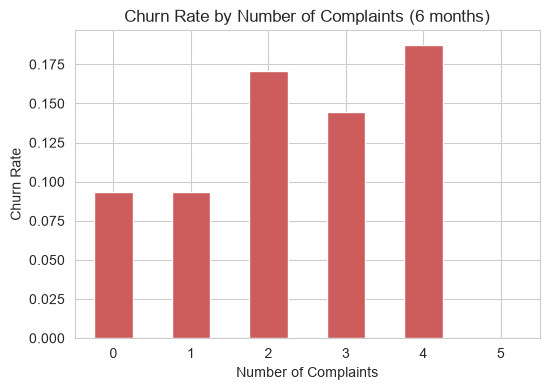

In [13]:
churn_by_complaints = df.groupby("num_complaints_6m")["churn"].mean()
print(churn_by_complaints)

plt.figure(figsize=(6,4))
churn_by_complaints.plot(kind="bar", color="indianred")
plt.title("Churn Rate by Number of Complaints (6 months)")
plt.ylabel("Churn Rate")
plt.xlabel("Number of Complaints")
plt.xticks(rotation=0)
plt.show()

Churn by VLR active status:
 is_active_vlr
0    0.317411
1    0.086836
Name: churn, dtype: float64

Churn by recharge recency bucket:
 recharge_recency_bucket
0-7      0.084848
8-15     0.091781
16-30    0.091767
31-45    0.094228
45+      0.212000
Name: churn, dtype: float64


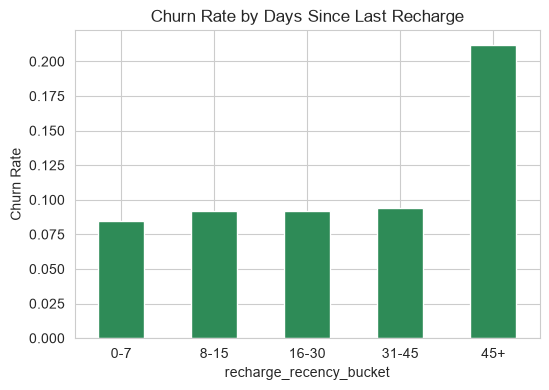

In [14]:
churn_by_vlr = df.groupby("is_active_vlr")["churn"].mean()
print("Churn by VLR active status:\n", churn_by_vlr)

# Bin days_since_last_recharge for readability
df["recharge_recency_bucket"] = pd.cut(
    df["days_since_last_recharge"],
    bins=[-1, 7, 15, 30, 45, 200],
    labels=["0-7", "8-15", "16-30", "31-45", "45+"]
)
churn_by_recency = df.groupby("recharge_recency_bucket")["churn"].mean()
print("\nChurn by recharge recency bucket:\n", churn_by_recency)

plt.figure(figsize=(6,4))
churn_by_recency.plot(kind="bar", color="seagreen")
plt.title("Churn Rate by Days Since Last Recharge")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

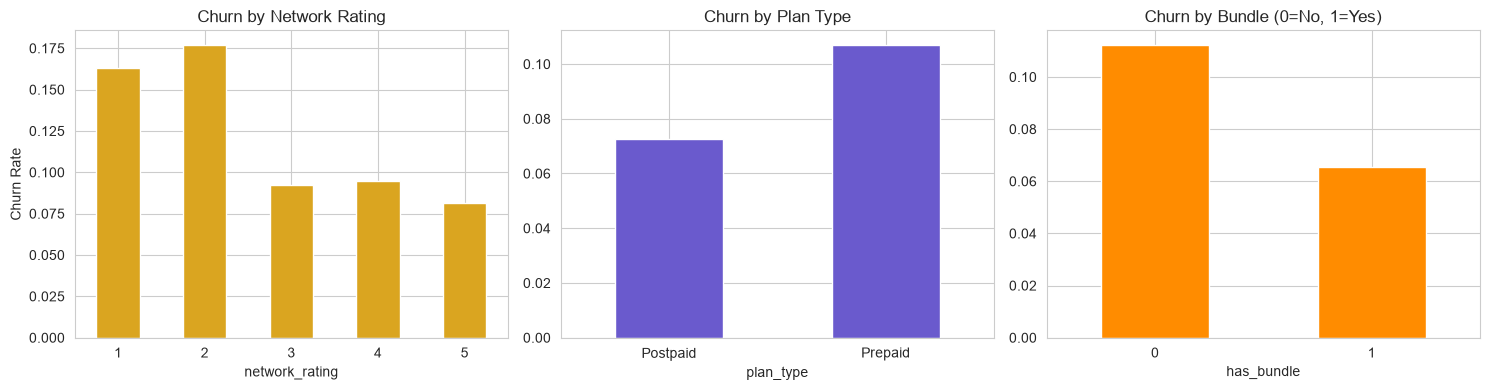

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df.groupby("network_rating")["churn"].mean().plot(kind="bar", ax=axes[0], color="goldenrod")
axes[0].set_title("Churn by Network Rating")
axes[0].set_ylabel("Churn Rate")

df.groupby("plan_type")["churn"].mean().plot(kind="bar", ax=axes[1], color="slateblue")
axes[1].set_title("Churn by Plan Type")

df.groupby("has_bundle")["churn"].mean().plot(kind="bar", ax=axes[2], color="darkorange")
axes[2].set_title("Churn by Bundle (0=No, 1=Yes)")

for ax in axes:
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

In [16]:
df["num_complaints_6m"].value_counts().sort_index()

num_complaints_6m
0    5560
1    3282
2     931
3     194
4      32
5       1
Name: count, dtype: int64

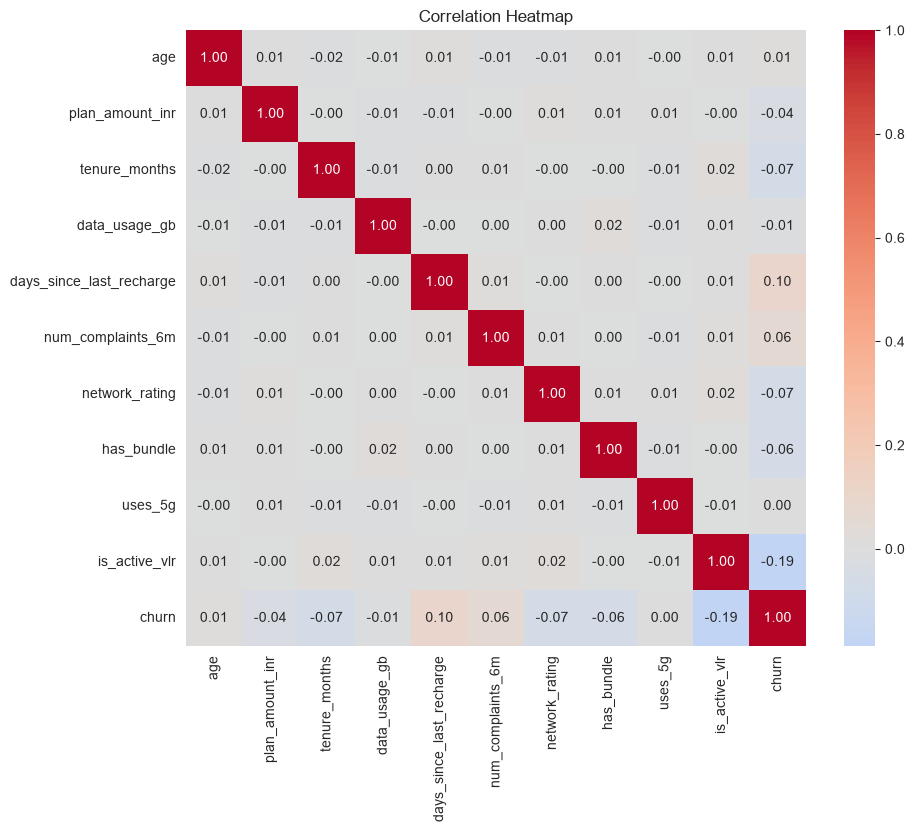


Correlation with churn (sorted):
churn                       1.000000
days_since_last_recharge    0.098479
num_complaints_6m           0.059011
age                         0.012583
uses_5g                     0.003410
data_usage_gb              -0.010405
plan_amount_inr            -0.036305
has_bundle                 -0.064452
network_rating             -0.070787
tenure_months              -0.072599
is_active_vlr              -0.187847
Name: churn, dtype: float64


In [17]:
numeric_for_corr = ["age", "plan_amount_inr", "tenure_months", "data_usage_gb",
                     "days_since_last_recharge", "num_complaints_6m", "network_rating",
                     "has_bundle", "uses_5g", "is_active_vlr", "churn"]

plt.figure(figsize=(10, 8))
corr = df[numeric_for_corr].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

print("\nCorrelation with churn (sorted):")
print(corr["churn"].sort_values(ascending=False))

## Key EDA Findings

1. **Overall churn rate is 10.2%** across 10,000 customers.
2. **Operator is a major driver**: Vi (21.2%) and BSNL (22.1%) customers churn at ~3x 
   the rate of Jio (6.6%) and Airtel (7.1%), consistent with TRAI's reported active-
   subscriber (VLR) ratios — Vi and BSNL have notably lower active-user percentages 
   nationally.
3. **VLR (active subscriber) status is the strongest individual signal** (correlation 
   -0.19): inactive customers churn at 31.7% vs 8.7% for active customers.
4. **Recharge recency matters past a threshold**: churn stays flat (~8-9%) up to 45 
   days since last recharge, then jumps to 21.2% beyond 45 days — suggesting a 
   "dormancy" cutoff worth monitoring operationally.
5. **Complaints show a positive trend** with churn (0 complaints: 9.3% → 4 complaints: 
   18.8%), though the n=5 group (1 customer) is excluded as statistically unreliable.
6. **Circle type (Metro/Urban/Rural) has minimal impact** on churn (9.7-10.7% range) — 
   geography alone doesn't explain churn in this dataset.
7. Individually weak linear correlations for tenure, network rating, bundles, and plan 
   amount suggest these may matter more through **interactions** — to be explored via 
   tree-based feature importance in modeling (Phase 3).

**Next steps**: preprocessing (encoding categoricals, feature engineering) and churn 
prediction modeling.